In [713]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

In [714]:

ruta = "fp.csv"
df = pd.read_csv(ruta)



In [715]:
df.head(10)

,id,Project,TeamExp,ManagerExp,YearEnd,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
0,1,1,1,4,85,12,5152,253,52,305,34,302,1
1,2,2,0,0,86,4,5635,197,124,321,33,315,1
2,3,3,4,4,85,1,805,40,60,100,18,83,1
3,4,4,0,0,86,5,3829,200,119,319,30,303,1
4,5,5,0,0,86,4,2149,140,94,234,24,208,1
5,6,6,0,0,86,4,2821,97,89,186,38,192,1
6,7,7,2,1,85,9,2569,119,42,161,25,145,2
7,8,8,1,2,83,13,3913,186,52,238,25,214,1
8,9,9,3,1,85,12,7854,172,88,260,30,247,1
9,10,10,3,4,83,4,2422,78,38,116,24,103,1


In [716]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               81 non-null     int64
 1   Project          81 non-null     int64
 2   TeamExp          81 non-null     int64
 3   ManagerExp       81 non-null     int64
 4   YearEnd          81 non-null     int64
 5   Length           81 non-null     int64
 6   Effort           81 non-null     int64
 7   Transactions     81 non-null     int64
 8   Entities         81 non-null     int64
 9   PointsNonAdjust  81 non-null     int64
 10  Adjustment       81 non-null     int64
 11  PointsAjust      81 non-null     int64
 12  Language         81 non-null     int64
dtypes: int64(13)
memory usage: 8.4 KB


In [717]:
columnas_a_eliminar = ['id', 'Project', 'YearEnd']
df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns], inplace=True)

In [718]:
target = 'Effort' 
features = [col for col in df.columns if col != target]

# Rellenar nulos con la mediana
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Información General y Estadísticos Descriptivos


In [719]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   TeamExp          81 non-null     int64
 1   ManagerExp       81 non-null     int64
 2   Length           81 non-null     int64
 3   Effort           81 non-null     int64
 4   Transactions     81 non-null     int64
 5   Entities         81 non-null     int64
 6   PointsNonAdjust  81 non-null     int64
 7   Adjustment       81 non-null     int64
 8   PointsAjust      81 non-null     int64
 9   Language         81 non-null     int64
dtypes: int64(10)
memory usage: 6.5 KB
None


Estadísticas Descriptivas (Variables Numéricas):

In [720]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TeamExp,81.0,2.185185,1.415195,-1.0,1.0,2.0,4.0,4.0
ManagerExp,81.0,2.530864,1.643825,-1.0,1.0,3.0,4.0,7.0
Length,81.0,11.666667,7.424621,1.0,6.0,10.0,14.0,39.0
Effort,81.0,5046.308642,4418.767228,546.0,2352.0,3647.0,5922.0,23940.0
Transactions,81.0,182.123457,144.035098,9.0,88.0,140.0,224.0,886.0
Entities,81.0,122.333333,84.882124,7.0,57.0,99.0,169.0,387.0
PointsNonAdjust,81.0,304.456790,180.210159,73.0,176.0,266.0,384.0,1127.0
Adjustment,81.0,27.629630,10.591795,5.0,20.0,28.0,35.0,52.0
PointsAjust,81.0,289.234568,185.761088,62.0,152.0,255.0,351.0,1116.0
Language,81.0,1.555556,0.707107,1.0,1.0,1.0,2.0,3.0


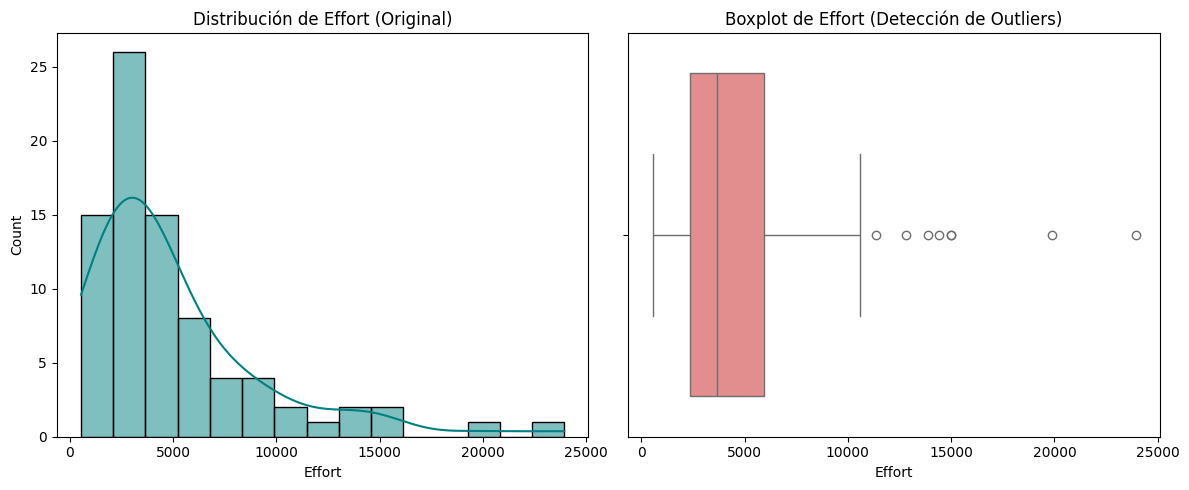

In [721]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Effort'], kde=True, color='teal')
plt.title('Distribución de Effort (Original)')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Effort'], color='lightcoral')
plt.title('Boxplot de Effort (Detección de Outliers)')
plt.tight_layout()
plt.show()

In [722]:
print(f"Dimensiones después de imputacion de valores faltantes: {df_clean.shape}")

Dimensiones después de imputacion de valores faltantes: (81, 10)


In [723]:
# Limpieza de Outliers (IQR)
df_clean = df.copy()
df_clean2 = df_clean.copy()
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5 * IQR) & (df_clean[col] <= Q3 + 1.5 * IQR)]


df_clean=df_clean2
print(f"Dimensiones después de limpieza: {df_clean.shape}")

Dimensiones después de limpieza: (81, 10)


# PARTICIÓN (70/30) Y ESCALADO (X e y)

In [724]:
X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar X
scaler_X = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), columns=features, index=X_test.index)

# Escalar y
scaler_y = StandardScaler()
y_train_scaled = pd.Series(scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index)
y_test_scaled = pd.Series(scaler_y.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)

# SELECCIÓN DE CARACTERÍSTICAS

In [725]:
corr_matrix_train = X_train_scaled.assign(**{target: y_train_scaled}).corr()
corr_target = corr_matrix_train[target].abs().sort_values(ascending=False).drop(target)

diferencias = np.diff(corr_target.values)
punto_corte = np.argmax(diferencias) + 3 
top_features = corr_target.index[:punto_corte].tolist()

print(f"\n--- Características seleccionadas (Top {punto_corte}):", top_features)


--- Características seleccionadas (Top 4): ['PointsAjust', 'PointsNonAdjust', 'Length', 'Transactions']


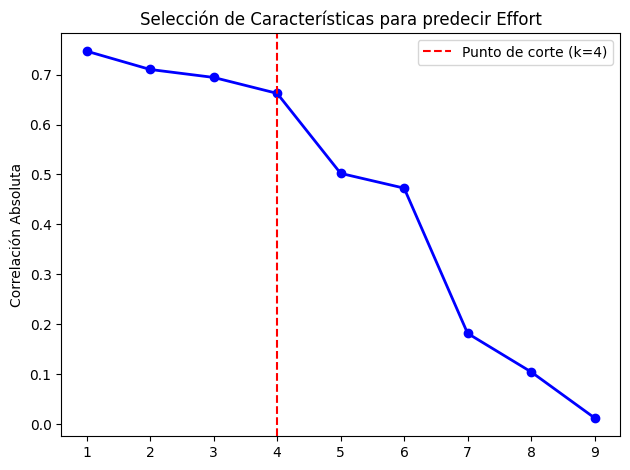

In [726]:
plt.plot(range(1, len(corr_target)+1), corr_target.values, 'bo-', linewidth=2)
plt.axvline(x=punto_corte, color='red', linestyle='--', label=f'Punto de corte (k={punto_corte})')
plt.title(f'Selección de Características para predecir {target}')
plt.ylabel('Correlación Absoluta')
plt.legend()
plt.tight_layout()
plt.show()


--- Importancia de Características (Árboles):
Length             0.5620
Transactions       0.2151
PointsNonAdjust    0.0750
PointsAjust        0.0651
Entities           0.0375
TeamExp            0.0171
Language           0.0164
ManagerExp         0.0102
Adjustment         0.0014
dtype: float64

--- Seleccionadas (Top 2): ['Length', 'Transactions']


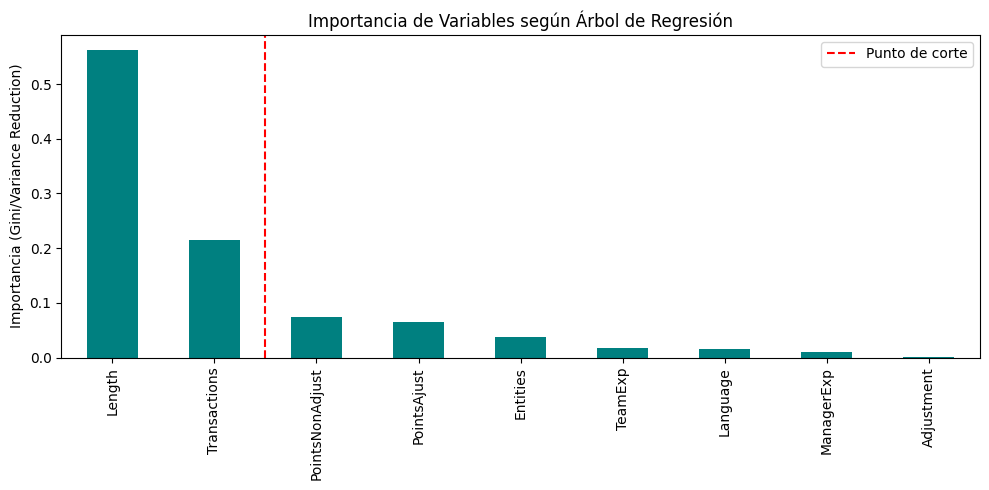

In [727]:

selector_tree = DecisionTreeRegressor(random_state=42)
selector_tree.fit(X_train_scaled, y_train_scaled)

# Extraer importancias y crear una serie
importancias = pd.Series(selector_tree.feature_importances_, index=features).sort_values(ascending=False)

# Definir punto de corte (ejemplo: variables que aportan más del 5% de importancia acumulada 
# o simplemente las top K que tú decidas)
# En este caso, usaremos el mismo concepto de "salto" o "codo" pero sobre las importancias
diferencias_imp = np.diff(importancias.values)
punto_corte_imp = np.argmax(np.abs(diferencias_imp)) + 2
top_features_tree = importancias.index[:punto_corte_imp].tolist()

print(f"\n--- Importancia de Características (Árboles):")
print(importancias.round(4))
print(f"\n--- Seleccionadas (Top {punto_corte_imp}): {top_features_tree}")

# Gráfica de Importancia
plt.figure(figsize=(10, 5))
importancias.plot(kind='bar', color='teal')
plt.axvline(x=punto_corte_imp - 0.5, color='red', linestyle='--', label='Punto de corte')
plt.title('Importancia de Variables según Árbol de Regresión')
plt.ylabel('Importancia (Gini/Variance Reduction)')
plt.legend()
plt.tight_layout()
plt.show()

# Seleccion de conjunto con todas las caracteristicas, y con las que son mejores

In [728]:
X_train_all = X_train_scaled
X_test_all = X_test_scaled

X_train_best = X_train_scaled[top_features]
X_test_best = X_test_scaled[top_features]

X_train_best_t= X_train_scaled[top_features_tree]
X_test_best_t = X_test_scaled[top_features_tree]

In [729]:
X_test_all.shape

(25, 9)

In [730]:
X_test_best.shape

(25, 4)

# Validacion cruzada

In [731]:
def cross_validation_kfold_reg(X, y, modelo_base, grid_parametros, k=5, nombre_modelo=""):
    X_arr = np.array(X)
    y_arr = np.array(y)
    indices = np.arange(len(X_arr))
    np.random.shuffle(indices)
    bloques_indices = np.array_split(indices, k)
    
    gamma_opt = None
    menor_error_medio = float('inf')
    
    print(f"\n--- Iniciando K-FOLD (k={k}) | Caso: {nombre_modelo} ---")
    
    for gamma in grid_parametros:
        print(f"\nEvaluando \u03B3: {gamma}")
        errores_k = []
        modelo_gamma = clone(modelo_base)
        modelo_gamma.set_params(**gamma)
        
        for i in range(k):
            idx_test = bloques_indices[i]
            idx_train = np.hstack([bloques_indices[j] for j in range(k) if j != i])
            
            modelo_gamma.fit(X_arr[idx_train], y_arr[idx_train])
            predicciones = modelo_gamma.predict(X_arr[idx_test])
            
            error_i = mean_squared_error(y_arr[idx_test], predicciones)
            errores_k.append(error_i)
            print(f"   -> Pliegue {i+1} | MSE: {error_i:.4f}")
        
        error_medio_gamma = np.mean(errores_k)
        print(f" => MSE medio E(\u03B3) = {error_medio_gamma:.4f}")
        
        if error_medio_gamma < menor_error_medio:
            menor_error_medio = error_medio_gamma
            gamma_opt = gamma
            
    print(f">>> \u03B3_opt elegido: {gamma_opt} (MSE mínimo: {menor_error_medio:.4f}) <<<")
    
    modelo_final = clone(modelo_base)
    modelo_final.set_params(**gamma_opt)
    modelo_final.fit(X_arr, y_arr)
    return modelo_final, gamma_opt, menor_error_medio

In [732]:
def leave_one_out_reg(X, y, modelo_base, grid_parametros, nombre_modelo=""):
    X_arr = np.array(X)
    y_arr = np.array(y)
    n = len(X_arr)
    
    gamma_opt = None
    menor_error_medio = float('inf')
    
    print(f"\n--- Iniciando LEAVE-ONE-OUT (n={n}) | Caso: {nombre_modelo} ---")
    
    for gamma in grid_parametros:
        print(f"Evaluando \u03B3: {gamma} ... ", end="")
        errores_n = []
        modelo_gamma = clone(modelo_base)
        modelo_gamma.set_params(**gamma)
        
        for i in range(n):
            X_test, y_test = X_arr[i:i+1], y_arr[i:i+1]
            X_train = np.delete(X_arr, i, axis=0)
            y_train = np.delete(y_arr, i, axis=0)
            
            modelo_gamma.fit(X_train, y_train)
            pred = modelo_gamma.predict(X_test)
            
            error_i = mean_squared_error(y_test, pred)
            errores_n.append(error_i)
        
        error_medio_gamma = np.mean(errores_n)
        print(f"MSE medio = {error_medio_gamma:.4f}")
        
        if error_medio_gamma < menor_error_medio:
            menor_error_medio = error_medio_gamma
            gamma_opt = gamma
            
    print(f">>> \u03B3_opt elegido: {gamma_opt} (MSE mínimo: {menor_error_medio:.4f}) <<<")
    
    modelo_final = clone(modelo_base)
    modelo_final.set_params(**gamma_opt)
    modelo_final.fit(X_arr, y_arr)
    return modelo_final, gamma_opt, menor_error_medio

In [733]:
dt_base = DecisionTreeRegressor(random_state=42)
rf_base = RandomForestRegressor(random_state=42)
lr_base = LinearRegression()

grid_dt = [{'max_depth': 3}, {'max_depth': 5}, {'max_depth': 10}, {'max_depth': None}]
grid_rf = [{'n_estimators': 10, 'max_depth': 5}, {'n_estimators': 50, 'max_depth': 10}]
grid_lr = [{}] 

modelos_finales = {}


# --- MODELOS A (Todas las variables) ---

In [734]:
print("="*70)

dt_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, dt_base, grid_dt, k=5)
rf_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, rf_base, grid_rf, k=5)
lr_all, _, _ = cross_validation_kfold_reg(X_train_all, y_train_scaled, lr_base, grid_lr, k=5)

modelos_finales['Árbol (Todas)'] = (dt_all, 'all')
modelos_finales['Random Forest (Todas)'] = (rf_all, 'all')
modelos_finales['Regresión Lineal (Todas)'] = (lr_all, 'all')




--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 1.2244
   -> Pliegue 2 | MSE: 0.2579
   -> Pliegue 3 | MSE: 2.3244
   -> Pliegue 4 | MSE: 0.2142
   -> Pliegue 5 | MSE: 0.9861
 => MSE medio E(γ) = 1.0014

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 0.5751
   -> Pliegue 2 | MSE: 1.0656
   -> Pliegue 3 | MSE: 1.3160
   -> Pliegue 4 | MSE: 0.8725
   -> Pliegue 5 | MSE: 1.1019
 => MSE medio E(γ) = 0.9862

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 1.0035
   -> Pliegue 2 | MSE: 1.0283
   -> Pliegue 3 | MSE: 1.3458
   -> Pliegue 4 | MSE: 0.3760
   -> Pliegue 5 | MSE: 0.9574
 => MSE medio E(γ) = 0.9422

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 1.0035
   -> Pliegue 2 | MSE: 1.0325
   -> Pliegue 3 | MSE: 1.3458
   -> Pliegue 4 | MSE: 0.1949
   -> Pliegue 5 | MSE: 1.0787
 => MSE medio E(γ) = 0.9311
>>> γ_opt elegido: {'max_depth': None} (MSE mínimo: 0.9311) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: 

# --- MODELOS B (Mejores variables) ---


In [735]:
# --- MODELOS B (Mejores variables) ---
dt_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, dt_base, grid_dt, k=5)
rf_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, rf_base, grid_rf, k=5)
lr_best, _, _ = cross_validation_kfold_reg(X_train_best, y_train_scaled, lr_base, grid_lr, k=5)

modelos_finales['Árbol (Mejores)'] = (dt_best, 'best')
modelos_finales['Random Forest (Mejores)'] = (rf_best, 'best')
modelos_finales['Regresión Lineal (Mejores)'] = (lr_best, 'best')


--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 0.5420
   -> Pliegue 2 | MSE: 0.3076
   -> Pliegue 3 | MSE: 2.0349
   -> Pliegue 4 | MSE: 1.9390
   -> Pliegue 5 | MSE: 0.6939
 => MSE medio E(γ) = 1.1035

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 0.5245
   -> Pliegue 2 | MSE: 0.2018
   -> Pliegue 3 | MSE: 2.1660
   -> Pliegue 4 | MSE: 2.4434
   -> Pliegue 5 | MSE: 1.2200
 => MSE medio E(γ) = 1.3111

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 0.4566
   -> Pliegue 2 | MSE: 0.1331
   -> Pliegue 3 | MSE: 2.3875
   -> Pliegue 4 | MSE: 1.8278
   -> Pliegue 5 | MSE: 1.2700
 => MSE medio E(γ) = 1.2150

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 0.4786
   -> Pliegue 2 | MSE: 0.6895
   -> Pliegue 3 | MSE: 2.1617
   -> Pliegue 4 | MSE: 1.8278
   -> Pliegue 5 | MSE: 1.2700
 => MSE medio E(γ) = 1.2855
>>> γ_opt elegido: {'max_depth': 3} (MSE mínimo: 1.1035) <<<

--- Iniciando K-FOLD (k=5) | Caso:  ---

Evaluando γ: {'n

In [736]:
# --- MODELOS C (Variables elegidas por Árboles) ---
dt_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, dt_base, grid_dt, k=5, nombre_modelo="DT Tree-Selected")
rf_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, rf_base, grid_rf, k=5, nombre_modelo="RF Tree-Selected")
lr_tree, _, _ = cross_validation_kfold_reg(X_train_best_t, y_train_scaled, lr_base, grid_lr, k=5, nombre_modelo="LR Tree-Selected")

modelos_finales['Árbol (Tree-Sel)'] = (dt_tree, 'tree')
modelos_finales['Random Forest (Tree-Sel)'] = (rf_tree, 'tree')
modelos_finales['Regresión Lineal (Tree-Sel)'] = (lr_tree, 'tree')


--- Iniciando K-FOLD (k=5) | Caso: DT Tree-Selected ---

Evaluando γ: {'max_depth': 3}
   -> Pliegue 1 | MSE: 0.9055
   -> Pliegue 2 | MSE: 2.0200
   -> Pliegue 3 | MSE: 0.2646
   -> Pliegue 4 | MSE: 1.8633
   -> Pliegue 5 | MSE: 2.4701
 => MSE medio E(γ) = 1.5047

Evaluando γ: {'max_depth': 5}
   -> Pliegue 1 | MSE: 1.1309
   -> Pliegue 2 | MSE: 2.0586
   -> Pliegue 3 | MSE: 0.4537
   -> Pliegue 4 | MSE: 1.6469
   -> Pliegue 5 | MSE: 2.6292
 => MSE medio E(γ) = 1.5839

Evaluando γ: {'max_depth': 10}
   -> Pliegue 1 | MSE: 0.8851
   -> Pliegue 2 | MSE: 2.0970
   -> Pliegue 3 | MSE: 0.5002
   -> Pliegue 4 | MSE: 0.5628
   -> Pliegue 5 | MSE: 2.8356
 => MSE medio E(γ) = 1.3762

Evaluando γ: {'max_depth': None}
   -> Pliegue 1 | MSE: 0.8291
   -> Pliegue 2 | MSE: 2.0750
   -> Pliegue 3 | MSE: 0.4958
   -> Pliegue 4 | MSE: 0.5627
   -> Pliegue 5 | MSE: 2.8363
 => MSE medio E(γ) = 1.3598
>>> γ_opt elegido: {'max_depth': None} (MSE mínimo: 1.3598) <<<

--- Iniciando K-FOLD (k=5) | Caso: RF 

EVALUACIÓN FINAL EN CONJUNTO DE PRUEBAS (30% TEST SET)

In [737]:
# =============================================================================
# 7. EVALUACIÓN FINAL (Métricas en Español - Estándar UTM)
# =============================================================================

def calcular_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

resultados = {}

for nombre, (modelo, tipo_datos) in modelos_finales.items():
    # Selección de conjunto de prueba según el tipo de entrenamiento
    if tipo_datos == 'all':
        X_test_eval = X_test_all
    elif tipo_datos == 'best':
        X_test_eval = X_test_best
    else: # tree
        X_test_eval = X_test_best_t
        
    y_pred_scaled = modelo.predict(X_test_eval)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    # Cálculo de métricas oficiales [cite: 31, 46]
    mse_val = mean_squared_error(y_test_scaled, y_pred_scaled)
    
    resultados[nombre] = {
        'Error Cuadrático Medio (MSE)': mse_val,
        'Raíz del MSE (RMSE)': np.sqrt(mse_val),
        'Error Absoluto Medio (MAE)': mean_absolute_error(y_test_scaled, y_pred_scaled),
        'R-cuadrado (R2)': r2_score(y_test_scaled, y_pred_scaled)
    }

# Crear DataFrame y mostrar resultados
df_resultados = pd.DataFrame(resultados).T
print("\n--- EVALUACIÓN DE DESEMPEÑO DE MODELOS ---")
print(df_resultados.round(4))


--- EVALUACIÓN DE DESEMPEÑO DE MODELOS ---
                             Error Cuadrático Medio (MSE)  \
Árbol (Todas)                                      0.4588   
Random Forest (Todas)                              0.3460   
Regresión Lineal (Todas)                           0.3539   
Árbol (Mejores)                                    0.5783   
Random Forest (Mejores)                            0.3823   
Regresión Lineal (Mejores)                         0.3173   
Árbol (Tree-Sel)                                   0.6531   
Random Forest (Tree-Sel)                           0.6026   
Regresión Lineal (Tree-Sel)                        0.3761   

                             Raíz del MSE (RMSE)  Error Absoluto Medio (MAE)  \
Árbol (Todas)                             0.6773                      0.4892   
Random Forest (Todas)                     0.5882                      0.4101   
Regresión Lineal (Todas)                  0.5949                      0.4187   
Árbol (Mejores)          

C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Marvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\val

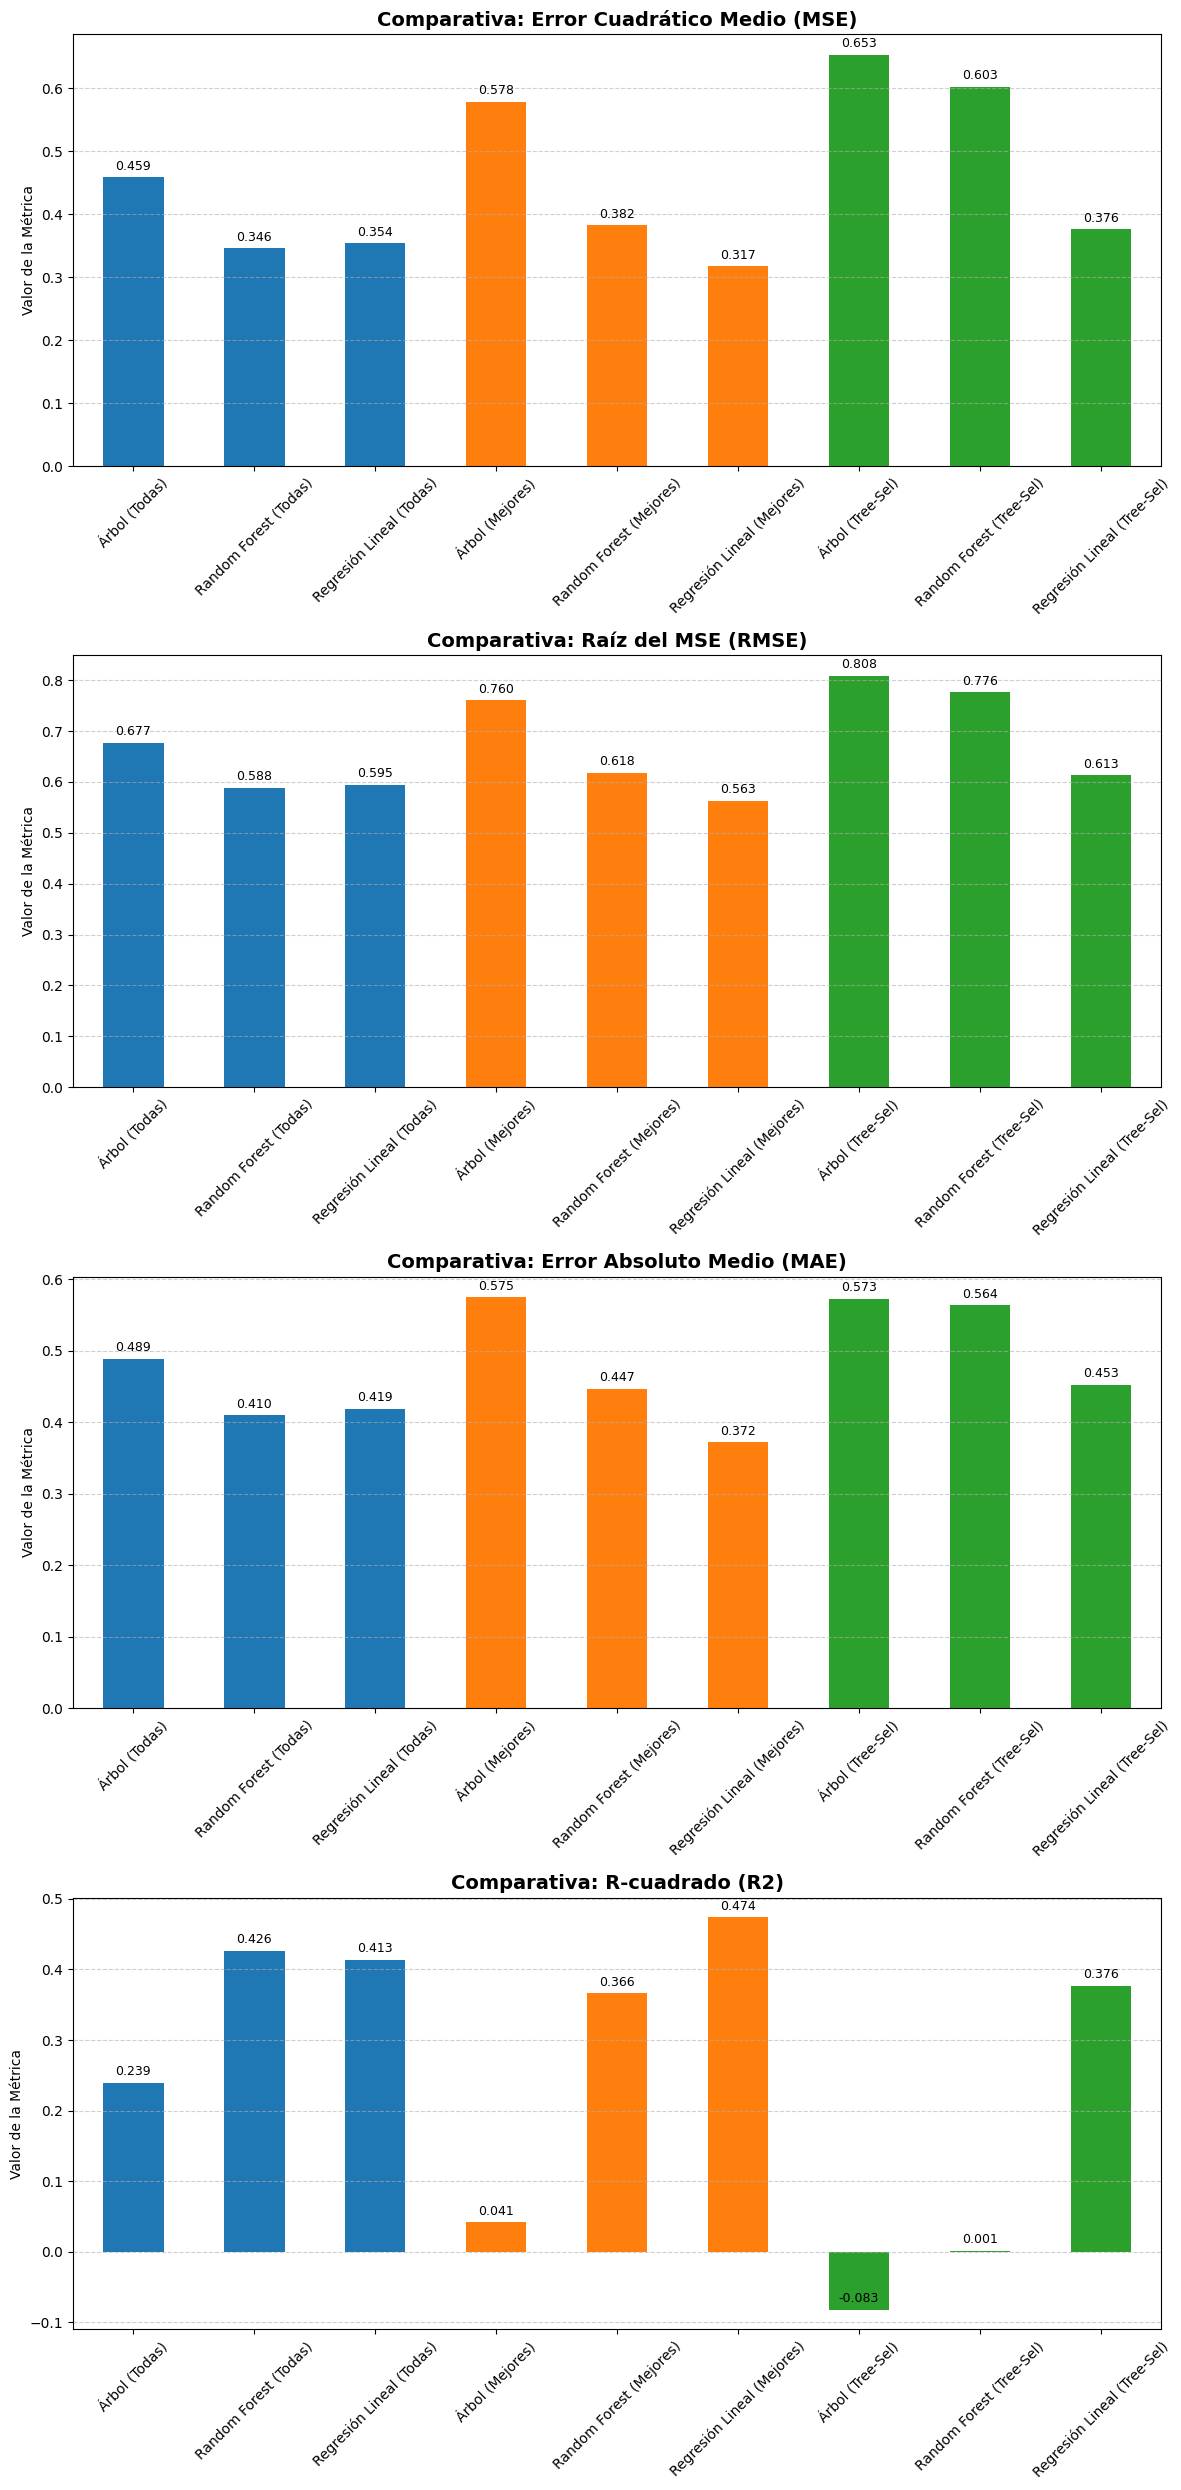

In [738]:
# =============================================================================
# 8. GRÁFICAS COMPARATIVAS POR MÉTRICA (ESTÁNDAR DE EVALUACIÓN)
# =============================================================================

# Definimos las métricas que queremos graficar (las que calculamos antes)
metricas = ['Error Cuadrático Medio (MSE)', 'Raíz del MSE (RMSE)', 
            'Error Absoluto Medio (MAE)', 
            'R-cuadrado (R2)']

# Configuración de colores (Azul: Todas, Naranja: Corr, Verde: Tree, Rojo: LOOCV)
colores = ['#1f77b4']*3 + ['#ff7f0e']*3 + ['#2ca02c']*3 + ['#d62728']

# Creamos una figura con varios subplots (uno para cada métrica)
fig, axes = plt.subplots(nrows=len(metricas), ncols=1, figsize=(12, 25))

for i, metrica in enumerate(metricas):
    # Graficar en el subplot correspondiente
    df_resultados[metrica].plot(kind='bar', color=colores[:len(df_resultados)], ax=axes[i])
    
    axes[i].set_title(f'Comparativa: {metrica}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Valor de la Métrica')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
    
    # Añadir los valores numéricos arriba de las barras
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 8), 
                         textcoords='offset points',
                         fontsize=9)

plt.tight_layout()
plt.show()